In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/cleaned_retail_data.csv'

In [2]:
import pandas as pd

df = pd.read_csv("cleaned_retail_data.csv")

df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_21984\3780165378.py:3: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cleaned_retail_data.csv")


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [3]:
df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

C:\Users\hp\AppData\Local\Temp\ipykernel_21984\1365172267.py:1: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/cleaned_retail_data.csv")


In [4]:
df["Sales"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [5]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1041671 entries, 0 to 1041670
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1041671 non-null  object        
 1   StockCode    1041671 non-null  str           
 2   Description  1041671 non-null  str           
 3   Quantity     1041671 non-null  int64         
 4   InvoiceDate  1041671 non-null  datetime64[us]
 5   Price        1041671 non-null  float64       
 6   Customer ID  805549 non-null   float64       
 7   Country      1041671 non-null  str           
 8   Sales        1041671 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(1), str(3)
memory usage: 71.5+ MB


In [6]:
snapshot_date = df["InvoiceDate"].max()

print(snapshot_date)

2011-12-09 12:50:00


In [7]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Sales": "sum"
})

In [8]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,12,77556.46
12347.0,1,8,5633.32
12348.0,74,5,2019.40
12349.0,18,4,4428.69
12350.0,309,1,334.40


In [9]:
rfm.shape

(5878, 3)

In [10]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,200.331916,6.290065,3018.616737
std,209.338707,13.010973,14737.731040
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,348.762500
50%,95.000000,3.000000,898.915000
75%,379.000000,7.000000,2307.090000
max,738.000000,398.000000,608821.650000


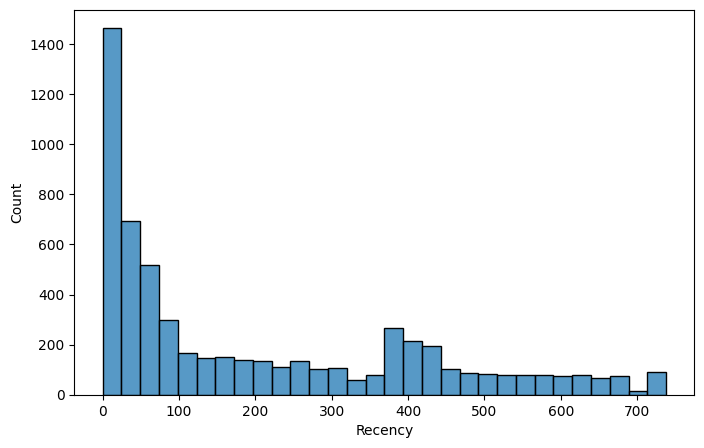

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(rfm["Recency"], bins=30)
plt.show()

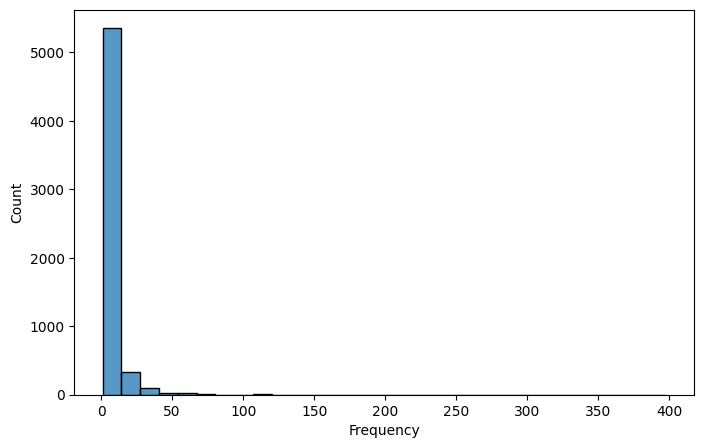

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(rfm["Frequency"], bins=30)
plt.show()

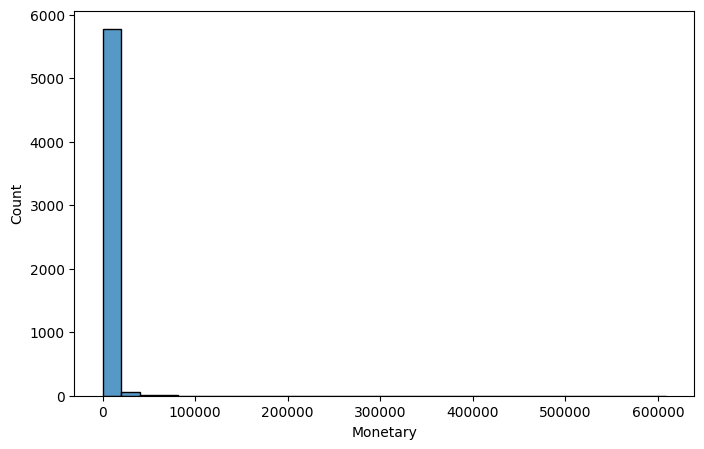

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(rfm["Monetary"], bins=30)
plt.show()

In [14]:
rfm.head()
rfm.shape
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,200.331916,6.290065,3018.616737
std,209.338707,13.010973,14737.731040
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,348.762500
50%,95.000000,3.000000,898.915000
75%,379.000000,7.000000,2307.090000
max,738.000000,398.000000,608821.650000


In [15]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
Customer ID,,,,,,
12346.0,325,12,77556.46,2,5,5
12347.0,1,8,5633.32,5,4,5
12348.0,74,5,2019.40,3,4,4
12349.0,18,4,4428.69,5,3,5
12350.0,309,1,334.40,2,1,2


In [16]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,325,12,77556.46,2,5,5,255
12347.0,1,8,5633.32,5,4,5,545
12348.0,74,5,2019.40,3,4,4,344
12349.0,18,4,4428.69,5,3,5,535
12350.0,309,1,334.40,2,1,2,212


In [17]:
rfm.sort_values(
    by="RFM_Score",
    ascending=False
).head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
16705.0,0,42,43515.051,5,5,5,555
14572.0,2,11,5615.180,5,5,5,555
18055.0,6,14,11195.570,5,5,5,555
17173.0,4,8,3766.600,5,5,5,555
14505.0,16,19,12001.840,5,5,5,555
13709.0,3,18,7591.750,5,5,5,555
12955.0,0,11,4757.160,5,5,5,555
14515.0,17,12,3749.260,5,5,5,555
12957.0,9,13,8706.970,5,5,5,555


In [18]:
rfm["RFM_Score"].value_counts().head(20)

RFM_Score
555    474
111    320
455    249
121    173
344    167
211    162
112    149
444    147
122    137
544    134
355    132
222    122
221    116
233    112
333    108
433    107
232     98
212     96
311     94
554     93
Name: count, dtype: int64

In [19]:
def segment_customer(row):
    
    if row["RFM_Score"] == "555":
        return "Champion"
    
    elif row["R_Score"] >= 4 and row["F_Score"] >= 4:
        return "Loyal Customer"
    
    elif row["R_Score"] >= 4:
        return "Potential Loyalist"
    
    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"
    
    else:
        return "Others"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12346.0,325,12,77556.46,2,5,5,255,At Risk
12347.0,1,8,5633.32,5,4,5,545,Loyal Customer
12348.0,74,5,2019.40,3,4,4,344,Others
12349.0,18,4,4428.69,5,3,5,535,Potential Loyalist
12350.0,309,1,334.40,2,1,2,212,Others


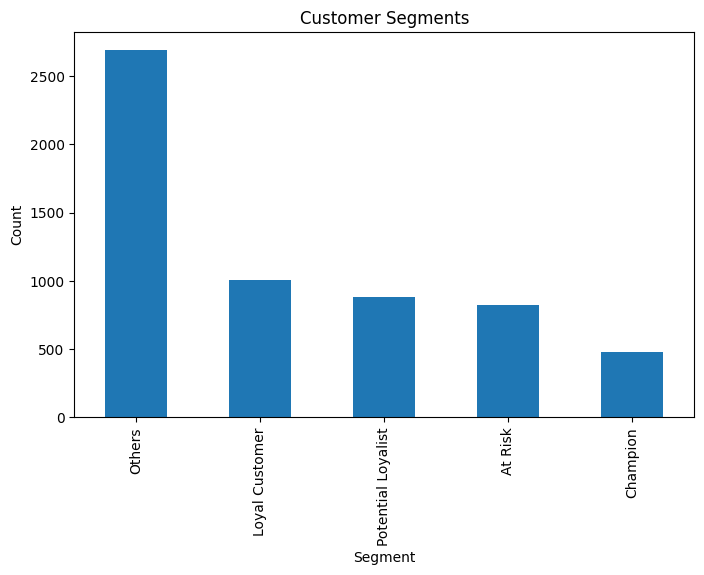

In [20]:
plt.figure(figsize=(8,5))

rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.ylabel("Count")
plt.show()

In [21]:
rfm["Segment"].value_counts()

Segment
Others                2690
Loyal Customer        1008
Potential Loyalist     882
At Risk                824
Champion               474
Name: count, dtype: int64

In [22]:
rfm.to_csv(
    "../data/processed/rfm_customer_segments.csv",
    index=True
)

print("RFM dataset saved successfully!")

RFM dataset saved successfully!
